# コンペ2

### 必要なライブラリのインポート

In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     
import seaborn as sns

### データの読み込み

In [246]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')
print("Train shape:", train.shape, "Test shape:", test.shape)
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)

Train shape: (2781, 16) Test shape: (696, 15)


### 基本情報のまとめ

In [247]:
# ===== 基本情報 =====
print("▼ データの先頭5行")
print(all_data.head())

print("\n▼ データの基本情報")
print(all_data.info())


▼ データの先頭5行
   Id  Year   Age             School  Height      Weight  Sprint_40yd  \
0   0  2011  21.0             Lehigh  1.9050  140.160042         5.39   
1   1  2011  24.0  Abilene Christian  1.8288   87.089735         4.31   
2   2  2018  21.0       Colorado St.  1.8542   92.986436         4.51   
3   3  2010  21.0      East Carolina  1.9304  148.778297         5.09   
4   4  2016  21.0         California  1.8796   92.079251         4.64   

   Vertical_Jump  Bench_Press_Reps  Broad_Jump  Agility_3cone  Shuttle  \
0          59.69              29.0      251.46           7.91     4.94   
1         101.60              16.0      332.74            NaN      NaN   
2          91.44              10.0      309.88           6.95     4.37   
3          76.20              39.0      254.00           8.12     4.71   
4          78.74               NaN      281.94           7.13     4.20   

  Player_Type      Position_Type Position  Drafted  
0     offense  offensive_lineman       OG      1.0  

In [248]:
print("\n▼ 数値列の統計量")
print(all_data.describe())


▼ 数値列の統計量
               Id         Year          Age       Height       Weight  \
count  3477.00000  3477.000000  2927.000000  3477.000000  3477.000000   
mean   1738.00000  2013.823699    21.983259     1.873968   109.746393   
std    1003.86777     3.075616     0.969490     0.067494    20.483780   
min       0.00000  2009.000000    18.000000     1.651000    67.585263   
25%     869.00000  2011.000000    21.000000     1.828800    92.986436   
50%    1738.00000  2014.000000    22.000000     1.879600   104.779837   
75%    2607.00000  2016.000000    23.000000     1.930400   125.645087   
max    3476.00000  2019.000000    28.000000     2.082800   167.375585   

       Sprint_40yd  Vertical_Jump  Bench_Press_Reps   Broad_Jump  \
count  3303.000000    2780.000000       2572.000000  2749.000000   
mean      4.769080      83.392403         20.241058   291.629698   
std       0.301477      10.678403          6.497600    23.960879   
min       4.220000      44.450000          2.000000   198.1

In [249]:
print("\n▼ 欠損値の数")
print(all_data.isnull().sum())


▼ 欠損値の数
Id                     0
Year                   0
Age                  550
School                 0
Height                 0
Weight                 0
Sprint_40yd          174
Vertical_Jump        697
Bench_Press_Reps     905
Broad_Jump           728
Agility_3cone       1217
Shuttle             1140
Player_Type            0
Position_Type          0
Position               0
Drafted              696
dtype: int64


##### データの確認

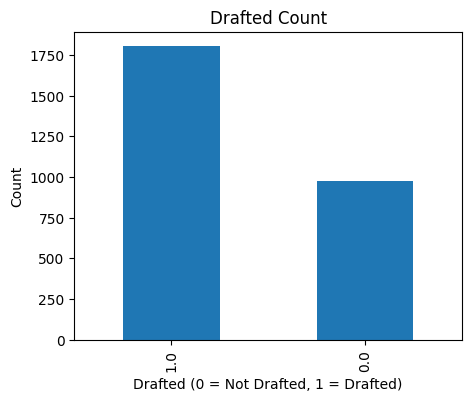

In [250]:
plt.figure(figsize=(5,4))
all_data['Drafted'].value_counts().plot(kind='bar')
plt.title("Drafted Count")
plt.xlabel("Drafted (0 = Not Drafted, 1 = Drafted)")
plt.ylabel("Count")
plt.show()


3分の2くらいがDraftedされる

それぞれのデータの特徴
1. 数値データと非数値列(カテゴリ列)

In [251]:
# 数値データと非数値データの分離
numeric_cols = all_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = all_data.select_dtypes(exclude=[np.number]).columns.tolist()
print("\n▼ 数値列:", numeric_cols)
print("▼ 非数値列:", categorical_cols)


▼ 数値列: ['Id', 'Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Drafted']
▼ 非数値列: ['School', 'Player_Type', 'Position_Type', 'Position']



2. 「Id」「Drafted」列を除く数値データについて可視化

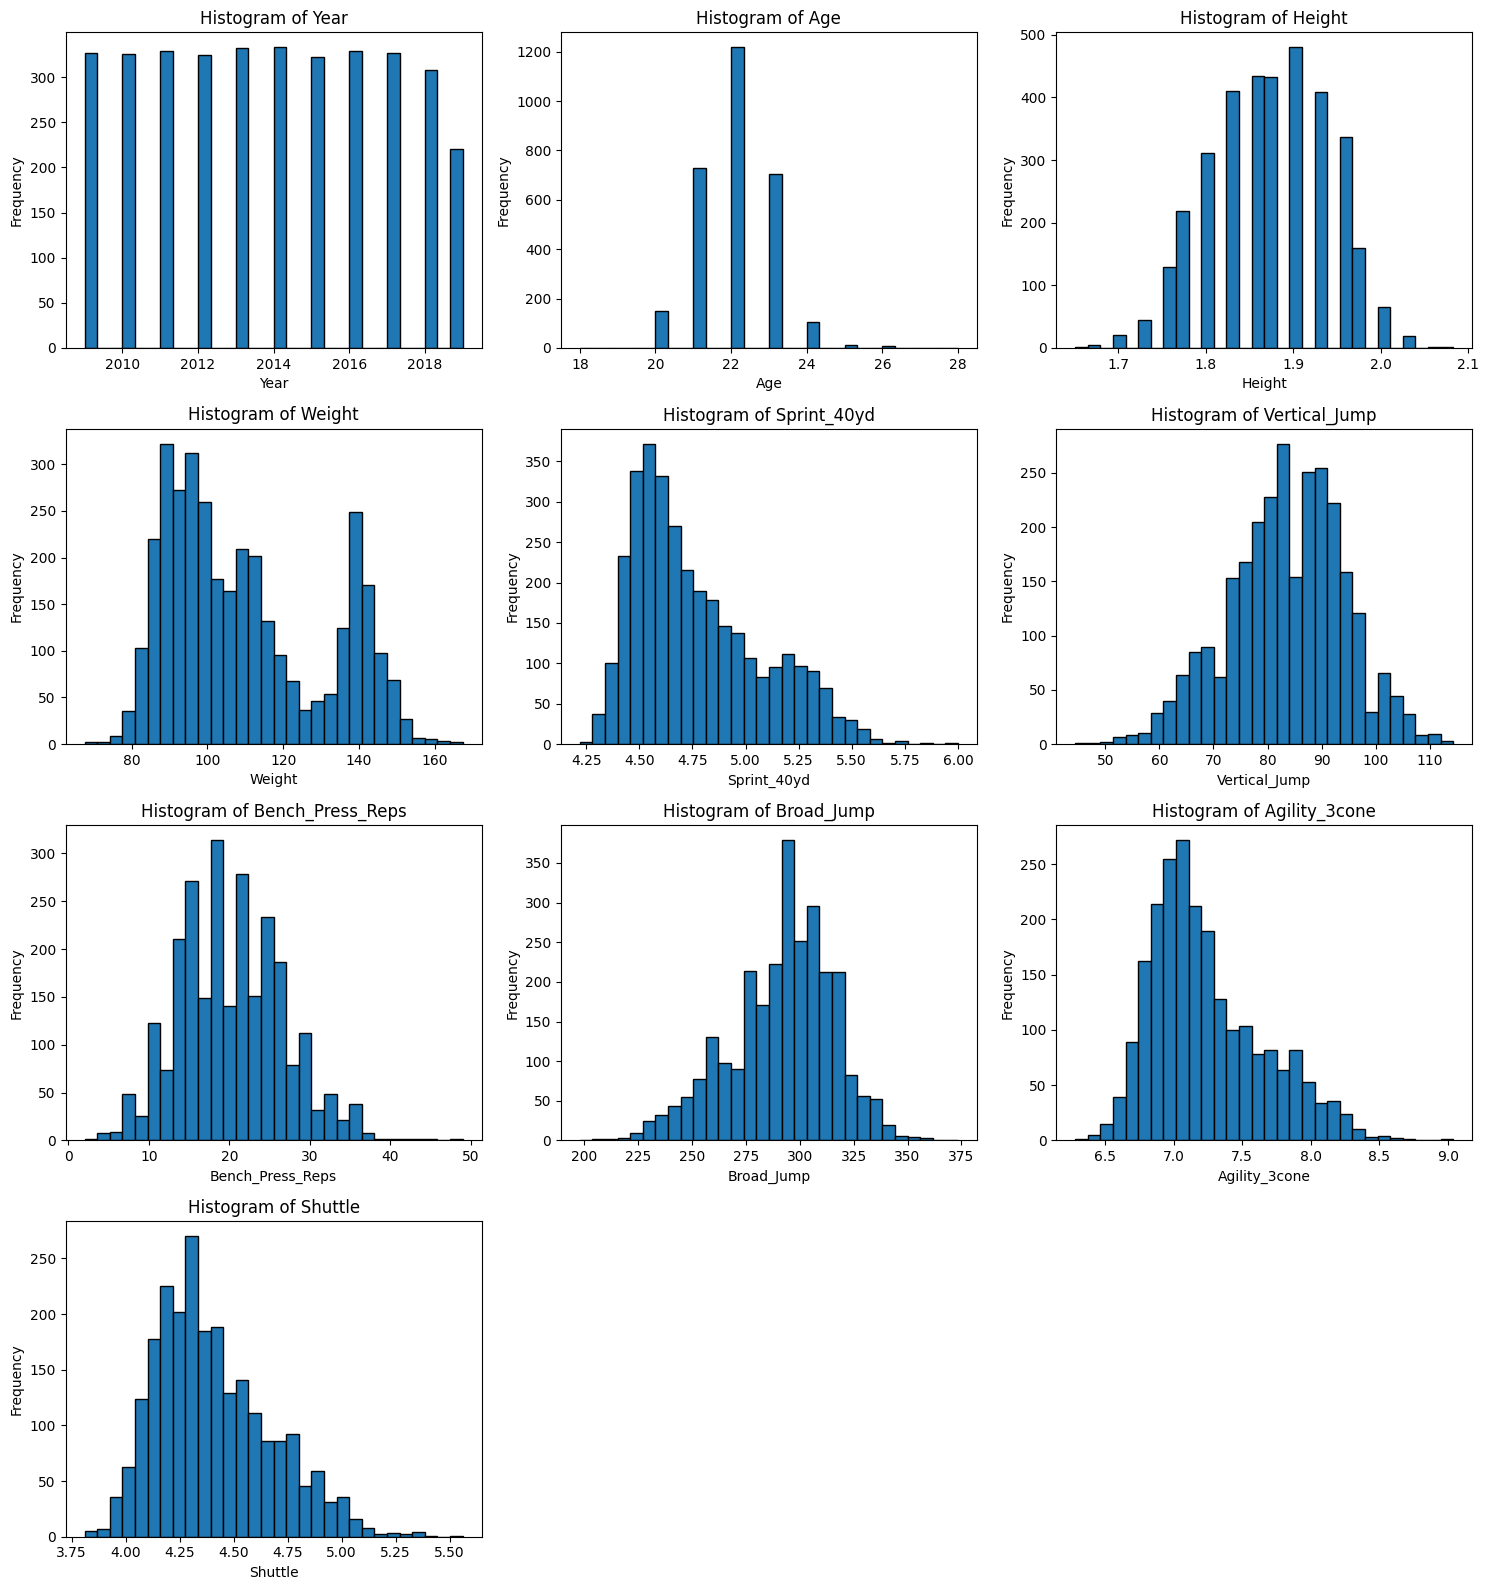

In [252]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = all_data.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# プロット
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(all_data[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

特徴量ごとの考察
1. Year: 2019だけ極端に少ないが年の影響はあまりなさそう
2. Age : 22で最大値　22+-2 が相場
3. Height: 正規分布
4. Weight: 山が2つ
5. Sprint_40yd: 4.5が最頻値
6. jump: 90が極端に少ない
7. Bench_Press_Reps: 
8. Broad_jump:
9. Agility_3cone:
10. Shuttle:

数値データの相関行列をヒートマップで確認

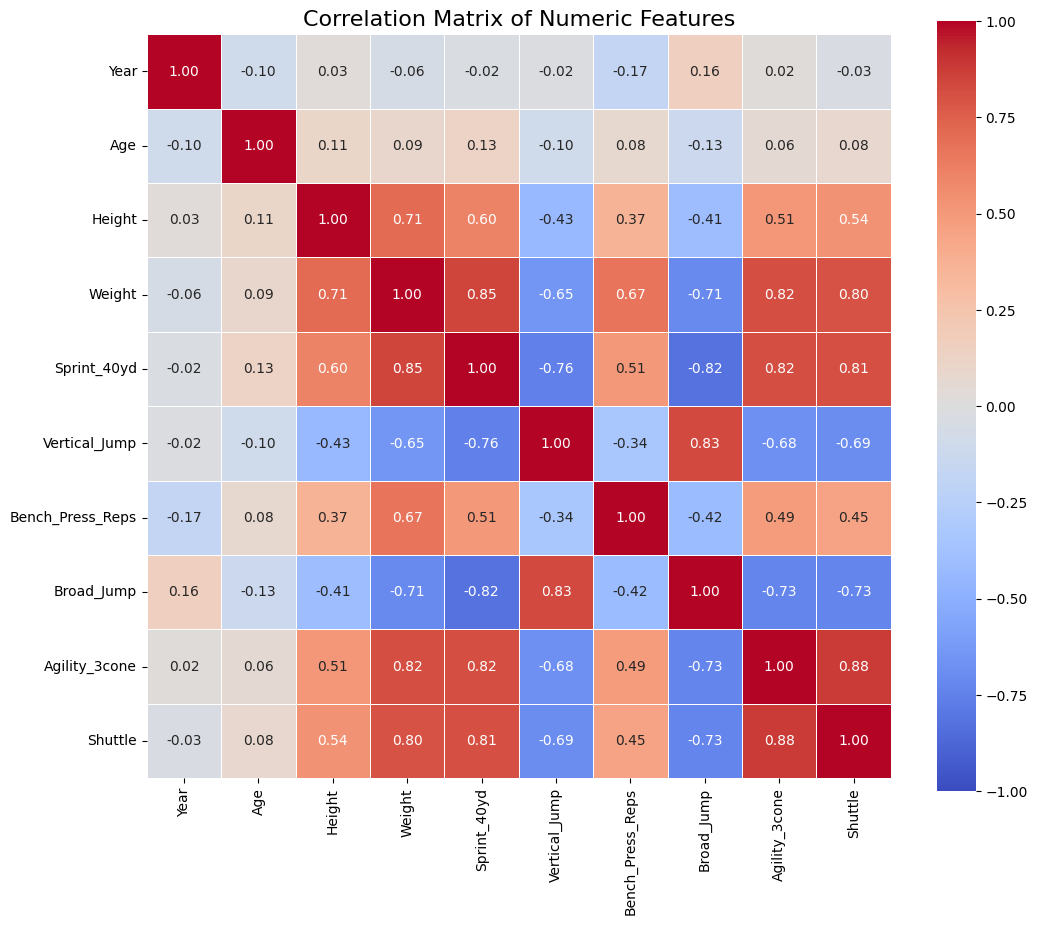

In [253]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = all_data.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# 相関行列を計算
corr_matrix = numeric_cols.corr()

# ヒートマップをプロット
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

「Sprint_40yd」列と「Broad_Jump」列の相関係数は-0.82で、強い負の相関関係が見らた。どちらも主に脚の力を使う種目であるため、通常はスコアが比例する（正の相関になる）と予想されるが、実際には逆の関係が見られる。この理由を探るため、「Sprint_40yd」列を可視化。

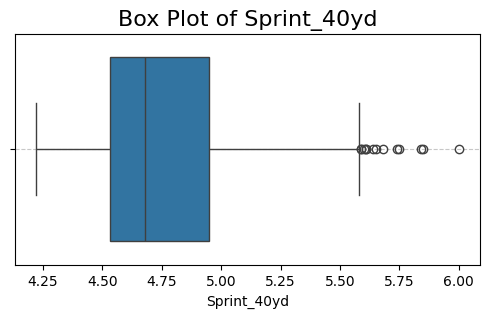

In [254]:
# 箱ひげ図を描画
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

可視化されたグラフを見ると、「Sprint_40yd」列の値はおおよそ4.25から6.00の範囲に分布していることがわかります。この数値はスコアではなく実際の走行タイムである可能性が高そうです。40ヤード（約36メートル）を走るタイムとして、中央値が約4.7秒であるのは妥当です。

　つまり、「Sprint_40yd」列の値が小さいほど速く走れたことを意味し、 数値が小さい＝パフォーマンスが高い という点で、他の 数値が大きいほど良い スコアとは逆の関係になっていたのです。

データを可視化することで、「なぜ負の相関があるのか？」という疑問を解決することができました。

In [255]:
# カテゴリデータを抽出
categorical_cols = all_data.select_dtypes(include=['object', 'category']).columns

# 各列の水準数を取得
levels_count = {col: all_data[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")

School: 253 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


Schoolは水準数が236とかなり多く、可視化すると潰れて見づらいのでここでは可視化しない

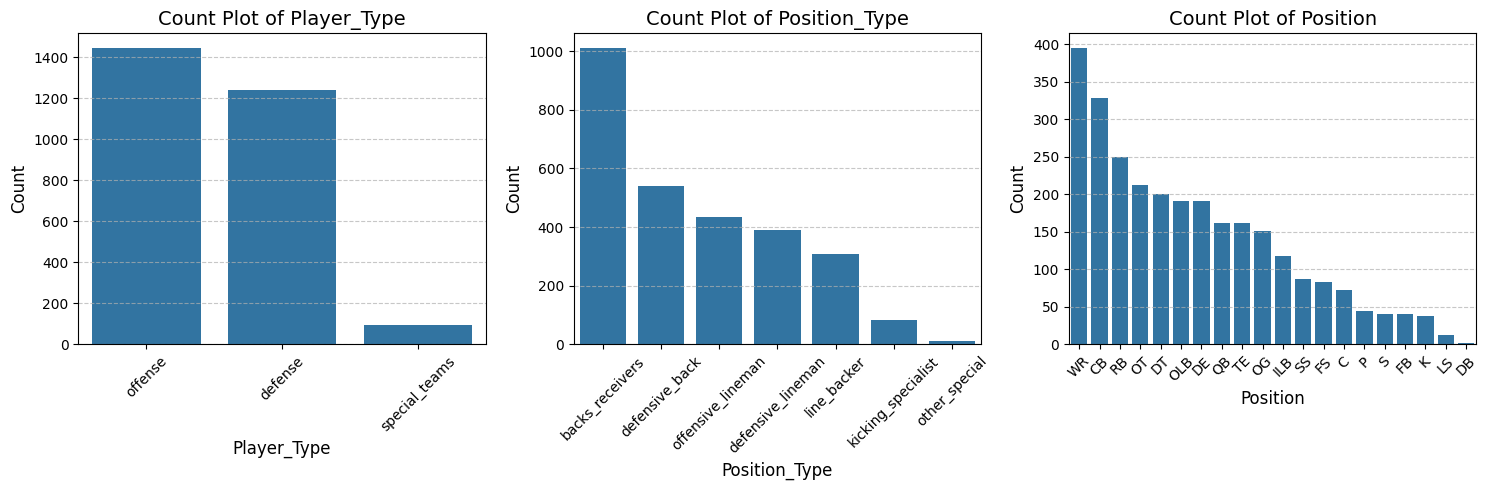

In [256]:
# カテゴリデータ（object型またはcategory型）を抽出し、School列を除外
categorical_cols = all_data.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数でカウントプロット
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

　水準によってデータ数に大きな差があるのが分かりました。例えば「Player_Type」列については、「special_teams」のデータ数がかなり少ないことが分かります。

次に、カテゴリデータについて、各水準の「Drafted列」の平均値を可視化してみましょう。この可視化を行うことで、どのポジションの選手がドラフトされやすいのかを視覚的に理解することができます。

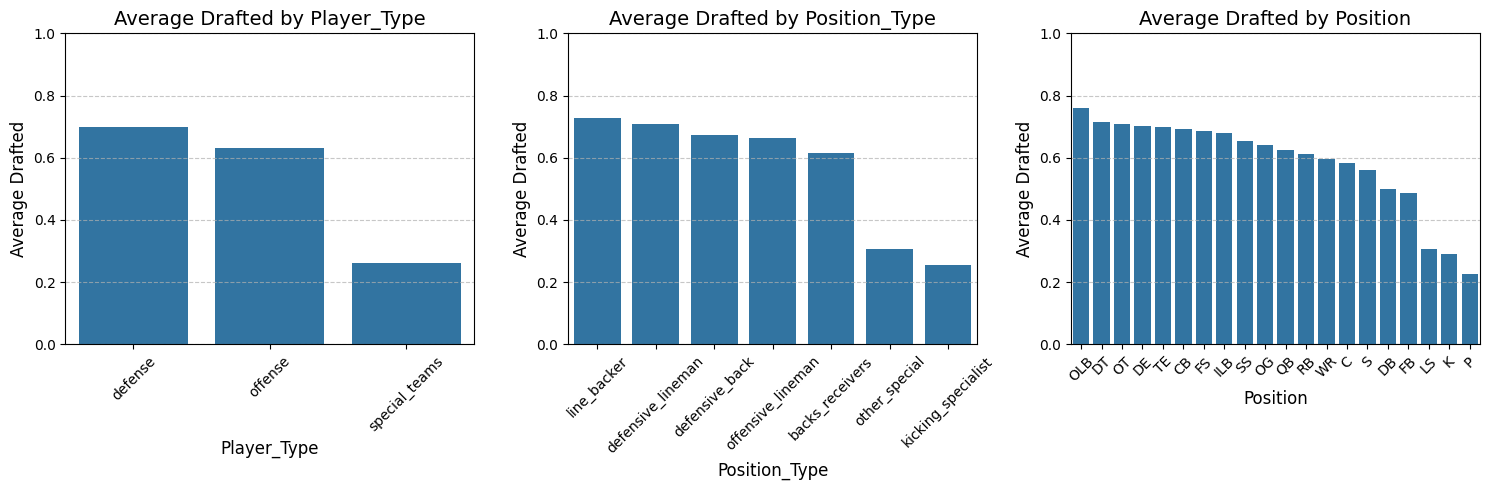

In [257]:
# カテゴリ変数（object型またはcategory型）を抽出し、School列を除外
categorical_cols = all_data.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数ごとに Drafted 列の平均を棒グラフで描画
for i, col in enumerate(categorical_cols):
    mean_values = all_data.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


「Player_Type」列が「special_teams」である選手は他の選手と比べてドラフト選出される割合がかなり低いことが分かります。
　また、「Position_Type」列が「other_special」「kicking_specialist」である選手、「Position」列が「LS」「K」「P」である選手もドラフト選出される割合が低いことが分かります。

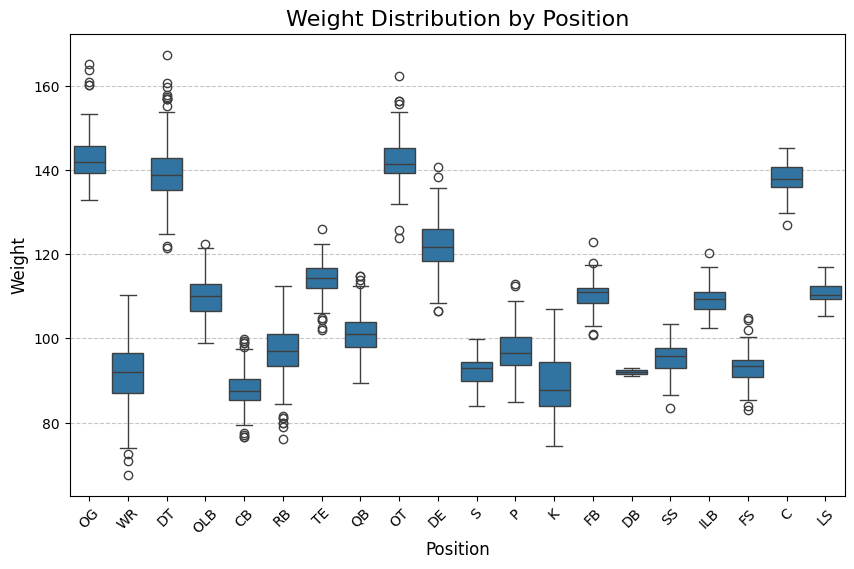

In [258]:
# WightとPositionの関係を箱ひげ図にして可視化
plt.figure(figsize=(10, 6))
sns.boxplot(x='Position', y='Weight', data=all_data)
plt.title('Weight Distribution by Position', fontsize=16)
plt.xlabel('Position', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

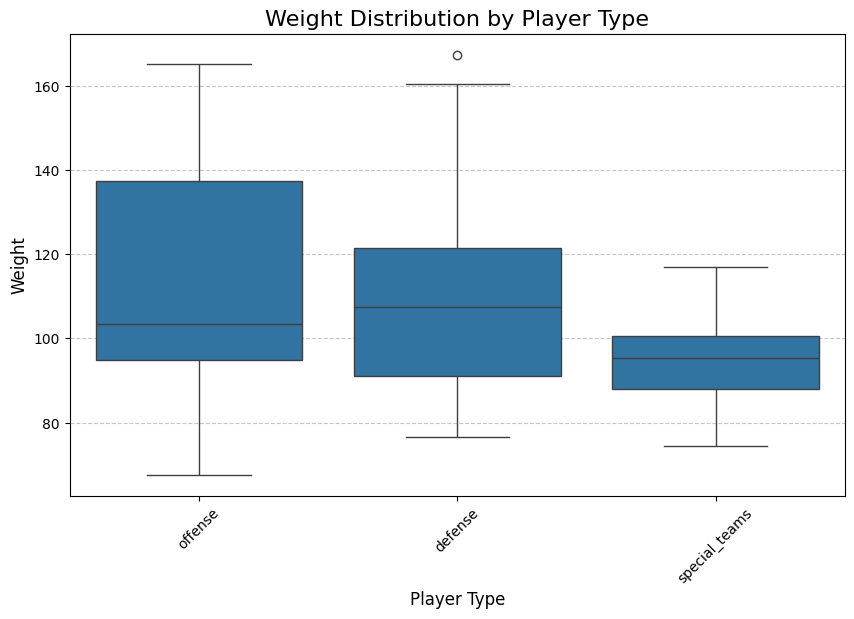

In [259]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Player_Type', y='Weight', data=all_data)
plt.title('Weight Distribution by Player Type', fontsize=16)
plt.xlabel('Player Type', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 前処理

1. 欠損値埋め
- ポジションごとの平均値で埋める

In [260]:
num_cols = ['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 
            'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in num_cols:
    # ポジションごとにグループ化して、その平均（または中央値）で埋める
    all_data[col] = all_data[col].fillna(all_data.groupby('Position')[col].transform('mean'))
    
    # それでも埋まらない場合（そのポジション全員が欠損している場合など）は全体の平均で埋める
    all_data[col] = all_data[col].fillna(all_data[col].mean())

2. Schoolの扱い方
- 問題点: 数が非常に多く、One-Hot Encodingすると列数が爆発的に増える
- 対応策: 出身大学ごとの人数に変換 -> 大学からのだラフト選出率に変換 -> 出現回数が少ない大学は"Others"としてまとめる　

In [261]:
from sklearn.model_selection import KFold


# ---------------------------------------------------------
# 1. Count Encoding (学校ごとのデータ出現数)
# ---------------------------------------------------------
print("Processing Count Encoding...")
school_counts = all_data['School'].value_counts()
all_data['School_Count'] = all_data['School'].map(school_counts)

# ---------------------------------------------------------
# 2. Target Encoding (学校ごとのドラフト選出率) 
# ---------------------------------------------------------
print("Processing Target Encoding...")

# TrainとTestを一時的に分離
train_df = all_data[all_data['Drafted'].notnull()].copy()
test_df = all_data[all_data['Drafted'].isnull()].copy()

# A. Trainデータへの適用（K-Foldを使用）
# 目的：自分の行の正解データを使わずに、同じ大学の「他の人たち」の平均を使う
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_df['School_Target'] = np.nan

for tr_idx, val_idx in kf.split(train_df):
    # 学習用データと検証用データに分割
    X_tr, X_val = train_df.iloc[tr_idx], train_df.iloc[val_idx]
    
    # 学習用データで大学ごとの「Drafted」平均を計算
    school_means = X_tr.groupby('School')['Drafted'].mean()
    
    # 検証用データにその平均をマップする
    train_df.loc[val_idx, 'School_Target'] = X_val['School'].map(school_means)

# B. Testデータへの適用（Train全体の平均を使用）
# Testデータには正解がないので、Train全体の統計を使うしかない
global_school_means = train_df.groupby('School')['Drafted'].mean()
test_df['School_Target'] = test_df['School'].map(global_school_means)

# C. 欠損値の処理（Trainに存在しない大学がTestに来た場合など）
# 全体のドラフト率で埋める
global_mean = train_df['Drafted'].mean()
train_df['School_Target'] = train_df['School_Target'].fillna(global_mean)
test_df['School_Target'] = test_df['School_Target'].fillna(global_mean)

# 再結合
all_data = pd.concat([train_df, test_df], sort=False).reset_index(drop=True)

# ---------------------------------------------------------
# 確認
# ---------------------------------------------------------
print("\n=== 作成された特徴量の確認 (Alabamaなどの強豪校の例) ===")
cols = ['School', 'School_Count', 'School_Target', 'Drafted']
print(all_data[all_data['School'] == 'Alabama'][cols].head())

print("\n=== 相関係数の確認（Draftedとの関係） ===")
# 数値列だけ抽出して相関を見る
corr = all_data[all_data['Drafted'].notnull()][['Drafted', 'School_Count', 'School_Target']].corr()
print(corr['Drafted'])

Processing Count Encoding...
Processing Target Encoding...

=== 作成された特徴量の確認 (Alabamaなどの強豪校の例) ===
      School  School_Count  School_Target  Drafted
66   Alabama           101       0.696970      1.0
111  Alabama           101       0.750000      0.0
214  Alabama           101       0.685185      1.0
368  Alabama           101       0.750000      1.0
418  Alabama           101       0.733333      1.0

=== 相関係数の確認（Draftedとの関係） ===
Drafted          1.000000
School_Count     0.097567
School_Target    0.031176
Name: Drafted, dtype: float64


In [262]:
# 出現回数が5回未満の大学を 'Others' に置換
counts = all_data['School'].value_counts()
rare_schools = counts[counts < 5].index

all_data['School_Cat'] = all_data['School'].apply(lambda x: 'Others' if x in rare_schools else x)

# その後、Label Encodingなどを行う
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
all_data['School_Label'] = le.fit_transform(all_data['School_Cat'])

3. ポジション別　標準化

In [263]:
print("Generating Z-scores by Position...")
for col in ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps']:
    # (値 - ポジション平均) / ポジション標準偏差
    # transformを使うと、グループごとの計算結果を元の行の数に合わせて返してくれます
    all_data[f'{col}_Z'] = all_data.groupby('Position')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8) # 0除算防止
    )

Generating Z-scores by Position...


4. ドメイン特徴量

In [264]:
# BMI (Body Mass Index): 体重(kg) / 身長(m)^2
# データセットの単位を確認: Heightはm, Weightはkgのようなのでそのまま計算
all_data['BMI'] = all_data['Weight'] / (all_data['Height'] ** 2)

# 運動量 (Momentum) のような指標: 体重 / 40yd走タイム
# (重いのに速い選手を評価する指標。タイムは分母)
all_data['Speed_Weight_Ratio'] = all_data['Weight'] / all_data['Sprint_40yd']

# 爆発力 (Explosiveness): 体重 * 垂直跳び
# (重い体を高く持ち上げられるパワー)
all_data['Explosiveness'] = all_data['Weight'] * all_data['Vertical_Jump']

# 敏捷性スコア (Agility_Score): 3コーン + シャトルラン
# (数値が小さいほど良い)
all_data['Agility_Score'] = all_data['Agility_3cone'] + all_data['Shuttle']

print("Added columns: BMI, Speed_Weight_Ratio, Explosiveness")


Added columns: BMI, Speed_Weight_Ratio, Explosiveness


6. 強豪校フラグ

In [265]:
powerhouse_schools=['Alabama', 'LSU', 'Ohio State', 'Florida', 'Georgia', 'Clemson', 
    'Oklahoma', 'Notre Dame', 'Michigan', 'Miami (FL)', 'Florida St.',
    'USC', 'Auburn', 'Penn State', 'Texas', 'Wisconsin', 'Stanford'
]
all_data['Is_Powerhouse'] = all_data['School'].apply(lambda x: 1 if x in powerhouse_schools else 0)

7. School×Position の掛け合わせ特徴量

In [266]:
# 例: "Alabama_WR", "Lehigh_OG" のような文字列を作る
all_data['School_Pos'] = all_data['School'] + '_' + all_data['Position']

# 1. Count Encoding (その大学のそのポジションから何人出ているか)
sp_counts = all_data['School_Pos'].value_counts()
all_data['School_Pos_Count'] = all_data['School_Pos'].map(sp_counts)

# 2. Target Encoding (Leakage対策のためKFold利用)
# ※コードが長くなるので、簡易的に既存の train_df を使って計算するロジックのみ示します
# 実際は前回の K-Fold ループ内に追加するのがベストですが、ここでは簡易実装します
train_subset = all_data[all_data['Drafted'].notnull()]
sp_means = train_subset.groupby('School_Pos')['Drafted'].mean()
# テストデータに存在してトレインにない組み合わせは、全体の平均で埋める
global_mean = train_subset['Drafted'].mean()
all_data['School_Pos_Target'] = all_data['School_Pos'].map(sp_means).fillna(global_mean)

# School_Pos 自体はカーディナリティが高すぎるので、モデルに入れる前に削除するか
# Label EncodingしてLightGBMに「カテゴリ」として扱わせます（今回はLabel Encoding採用）
le_sp = LabelEncoder()
all_data['School_Pos_Cat'] = le_sp.fit_transform(all_data['School_Pos'].astype(str))

8. K-Means クラスタリング(身体能力タイプ分類)

In [267]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_cols = [c for c in all_data.columns if c.endswith('_Z')] 
# もしZ-score列がまだ作られていなければ、元の数値列を使ってください

# 欠損があるとKMeansは動かないので、念のため0埋め等で対処（Z-scoreなら0は平均の意味なので安全）
cluster_data = all_data[cluster_cols].fillna(0)

# データを標準化（Z-score列なら既にされていますが、念のため）
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# 8つのタイプに分類（例: スピード型、パワー型、バランス型など）
kmeans = KMeans(n_clusters=8, random_state=42)
all_data['Physical_Cluster'] = kmeans.fit_predict(cluster_data_scaled)

# Cluster IDはそのままだと数値の大小に意味がないので、カテゴリとして扱うか、
# One-Hot Encodingするか、Target Encodingします。
# LightGBMならそのまま「カテゴリ変数」として指定すればOK

print("Added Features: Is_Powerhouse, School_Pos_Count, School_Pos_Target, Physical_Cluster")

Added Features: Is_Powerhouse, School_Pos_Count, School_Pos_Target, Physical_Cluster


5. カテゴリ変数の処理

In [268]:
# モデルが扱えるように数値に変換 (Label Encoding)
# School_Catも含めて数値化
cat_cols = ['Player_Type', 'Position_Type', 'Position', 'School_Cat', 
            'Physical_Cluster']
for col in cat_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))
# Schoolは既にCount/Target Encodingしたので、ここでは元の文字列列は削除するか無視します

for col in cat_cols:
    le = LabelEncoder()
    # 欠損値は 'NaN' という文字列にしてエンコードしてしまうのが手っ取り早い
    all_data[col] = all_data[col].fillna('NaN')
    all_data[col] = le.fit_transform(all_data[col].astype(str))
# 不要な列の削除
# Id: 識別子なので不要
# School: エンコーディング済みなので元の文字列は不要
# Year: 時代の変化があるかもしれないが、一旦ベースラインではノイズになりうるので外してみる（入れてもOK）
# School_Pos: エンコーディング済みなので元の文字列は不要
drop_cols = ['Id', 'School', 'Year','School_Pos']
all_data_model = all_data.drop(columns=drop_cols)

In [269]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

体重

In [275]:
# ポジションごとの平均体重を計算
pos_weight_mean = all_data_model.groupby('Position')['Weight'].transform('mean')

# 「平均との差」を新しい特徴量にする
all_data_model['Weight_Diff_Pos'] = all_data_model['Weight'] - pos_weight_mean
#
# または「平均比」にする
#all_data_model['Weight_Ratio_Pos'] = all_data_model['Weight'] / pos_weight_mean

In [292]:
# Speed Score (単純な例: 体重 × 200 / 40ヤードタイム^4) 
# Bill Barnwellが提唱した有名な指標などがあります
all_data_model['Speed_Score'] = (all_data_model['Weight'] * 200) / (all_data_model['Sprint_40yd']**4)

In [293]:
# 特徴量一覧
feature_cols = [c for c in all_data_model.columns if c != 'Drafted']
print("Feature columns:", feature_cols)

Feature columns: ['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Player_Type', 'Position_Type', 'Position', 'School_Count', 'School_Target', 'School_Cat', 'School_Label', 'Height_Z', 'Weight_Z', 'Sprint_40yd_Z', 'Vertical_Jump_Z', 'Bench_Press_Reps_Z', 'BMI', 'Speed_Weight_Ratio', 'Explosiveness', 'Agility_Score', 'Is_Powerhouse', 'School_Pos_Count', 'School_Pos_Target', 'School_Pos_Cat', 'Physical_Cluster', 'Weight_Diff_Pos', 'Speed_Score']


### モデル作成

In [296]:
from sklearn.model_selection import StratifiedKFold


# 1. 学習データとテストデータを all_data_model から抽出
# (DraftedがNaNでないものが学習データ、NaNなのがテストデータ)
train_subset = all_data_model[all_data_model['Drafted'].notnull()].copy()
test_subset = all_data_model[all_data_model['Drafted'].isnull()].copy()

# 2. X, y, test_df_for_pred の作成
drop_cols = ['Drafted', 'is_train', 'School_Pos_Cat','School_Pos_Target','Height_Z','Weight_Z','Weight','Height']

X = train_subset.drop(columns=drop_cols, errors='ignore')
y = train_subset['Drafted']
test_df_for_pred = test_subset.drop(columns=drop_cols, errors='ignore')

# 学習パラメータ
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'learning_rate': 0.05, # 少し学習率を下げて丁寧に学習させる
    'n_estimators': 2000,  # 木の数を増やす
    'random_state': 42,
    'colsample_bytree': 0.8, # 特徴量のサブサンプリング
    'max_depth': 7,
}

# Cross Validationで評価
folds = 5
kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
feature_importance_df = pd.DataFrame()

for n_fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    # 重要度保存
    fold_importance = pd.DataFrame()
    fold_importance["feature"] = X.columns
    fold_importance["importance"] = model.feature_importances_
    feature_importance_df = pd.concat([feature_importance_df, fold_importance], axis=0)

print(f"=== Overall CV AUC: {roc_auc_score(y, oof_preds):.4f} ===")

# 重要度TOP20表示
print("\n=== Feature Importance (Top 20) ===")
cols = (feature_importance_df[["feature", "importance"]]
        .groupby("feature")
        .mean()
        .sort_values(by="importance", ascending=False)[:20].index)
best_features = feature_importance_df.loc[feature_importance_df.feature.isin(cols)]
print(best_features.groupby('feature')['importance'].mean().sort_values(ascending=False))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[96]	valid_0's auc: 0.822333
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[48]	valid_0's auc: 0.856126
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[127]	valid_0's auc: 0.85158
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[170]	valid_0's auc: 0.807526
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[39]	valid_0's auc: 0.842971
=== Overall CV AUC: 0.8308 ===

=== Feature Importance (Top 20) ===
feature
Age                   267.8
Sprint_40yd_Z         222.0
Speed_Score           180.2
School_Target         174.2
Weight_Diff_Pos       172.8
Explosiveness         159.8
Bench_Press_Reps_Z    143.4
Speed_Weight_Ratio    120.4
BMI                   103.6
Broad_Jump            103.0
Vertical_Jump

### 提出ファイルの作成

In [290]:
# 1. 予測用データの列を、学習データ(X)と完全に一致させる
# これで余計な 'Drafted' 列などが自動的に落ちます
test_df = all_data_model[all_data_model['Drafted'].isnull()][X.columns]

# 2. 予測を実行
y_pred_test  = model.predict_proba(test_df)[:, 1]

# 3. 提出用データフレームの作成
submission = pd.DataFrame({
    'Id': test['Id'],
    'Drafted': y_pred_test
})

# 4. CSV保存
submission.to_csv('submission.csv', index=False)

print("=== 完了: submission.csv が作成されました ===")
print(submission.head())

=== 完了: submission.csv が作成されました ===
     Id   Drafted
0  2781  0.791979
1  2782  0.822602
2  2783  0.862437
3  2784  0.887557
4  2785  0.801180
